# Lab 6: KNN Classification

## Aim
To implement K-Nearest Neighbors (KNN) classification using Python.

## Requirements
- Python
- NumPy
- Pandas
- Scikit-learn

In [ ]:
## Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix
import warnings



In [ ]:
## Load Dataset

data=pd.read_csv('/content/diabetes.csv')
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
diabetes_df = pd.DataFrame(data)
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes_df.describe(include='all')

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
diabetes_df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
diabetes_df.shape

(768, 9)

In [ ]:
diabetes_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
diabetes_df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


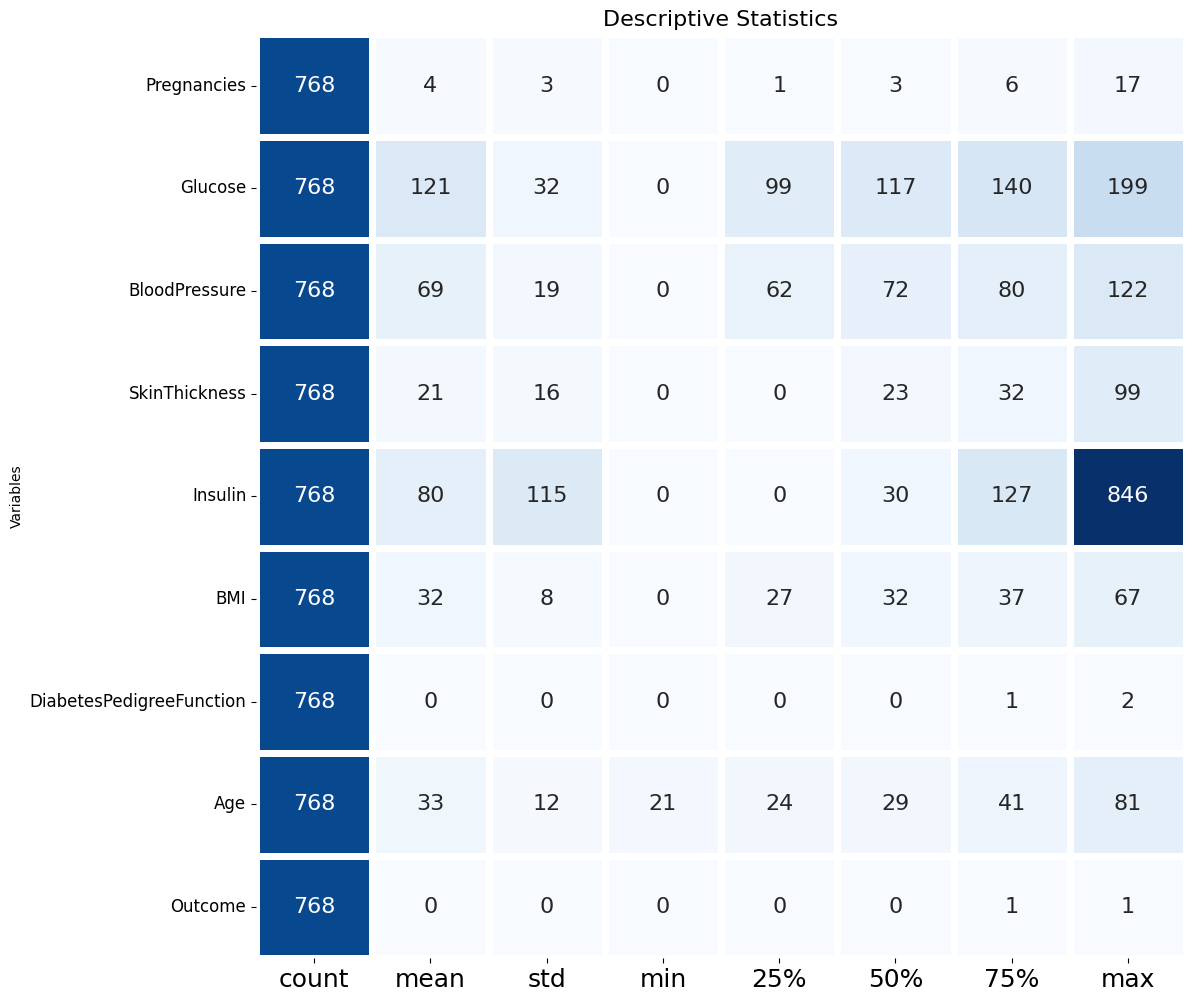

In [ ]:
# Show detaile data set
desc = diabetes_df.describe().T
diabets_df2 = pd.DataFrame(index=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                          'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
                   columns= ["count","mean","std","min",
                             "25%","50%","75%","max"], data= desc )

f,ax = plt.subplots(figsize=(12,12))

sns.heatmap(diabets_df2, annot=True,cmap = "Blues", fmt= '.0f',
            ax=ax,linewidths = 5, cbar = False,
            annot_kws={"size": 16})

plt.xticks(size = 18)
plt.yticks(size = 12, rotation = 0)
plt.ylabel("Variables")
plt.title("Descriptive Statistics", size = 16)
plt.show()

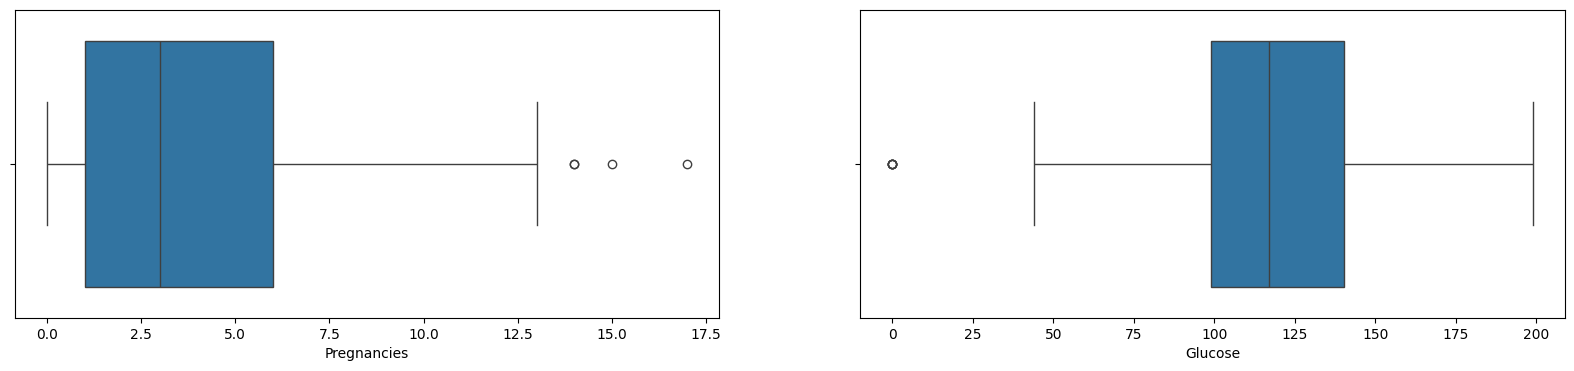

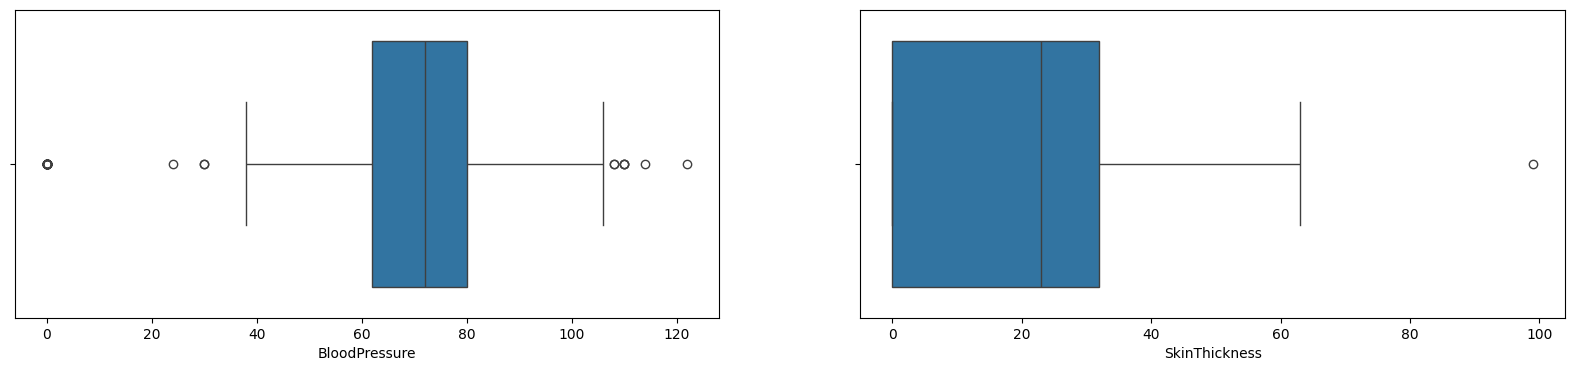

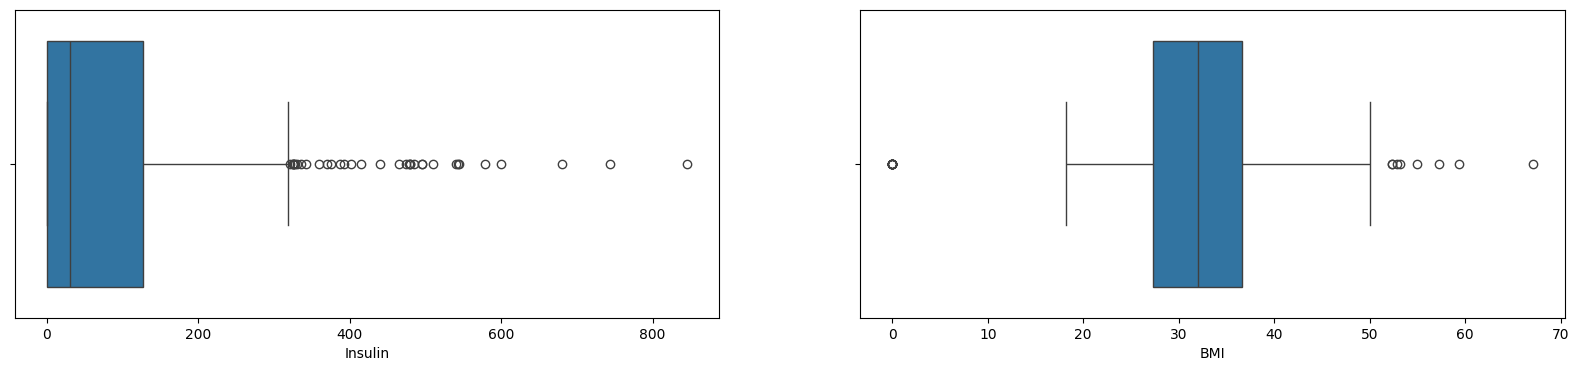

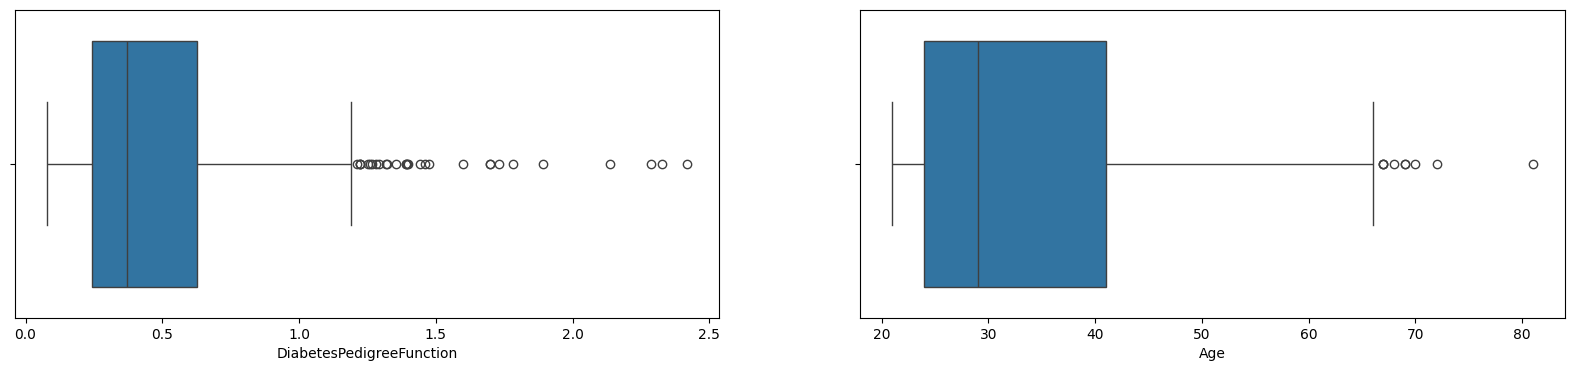

In [ ]:
## plot for numerical columns
Numerical = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness','Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
i = 0
while i <8:
    fig = plt.figure(figsize =[20,4])
    plt.subplot(1,2,1)   #(one row, two plots, firs one)
    sns.boxplot(x =Numerical[i], data = diabetes_df )
    i+=1
    if i==8:
        break
    plt.subplot(1,2,2)
    sns.boxplot(x =Numerical[i], data = diabetes_df)
    i+=1

    plt.show()

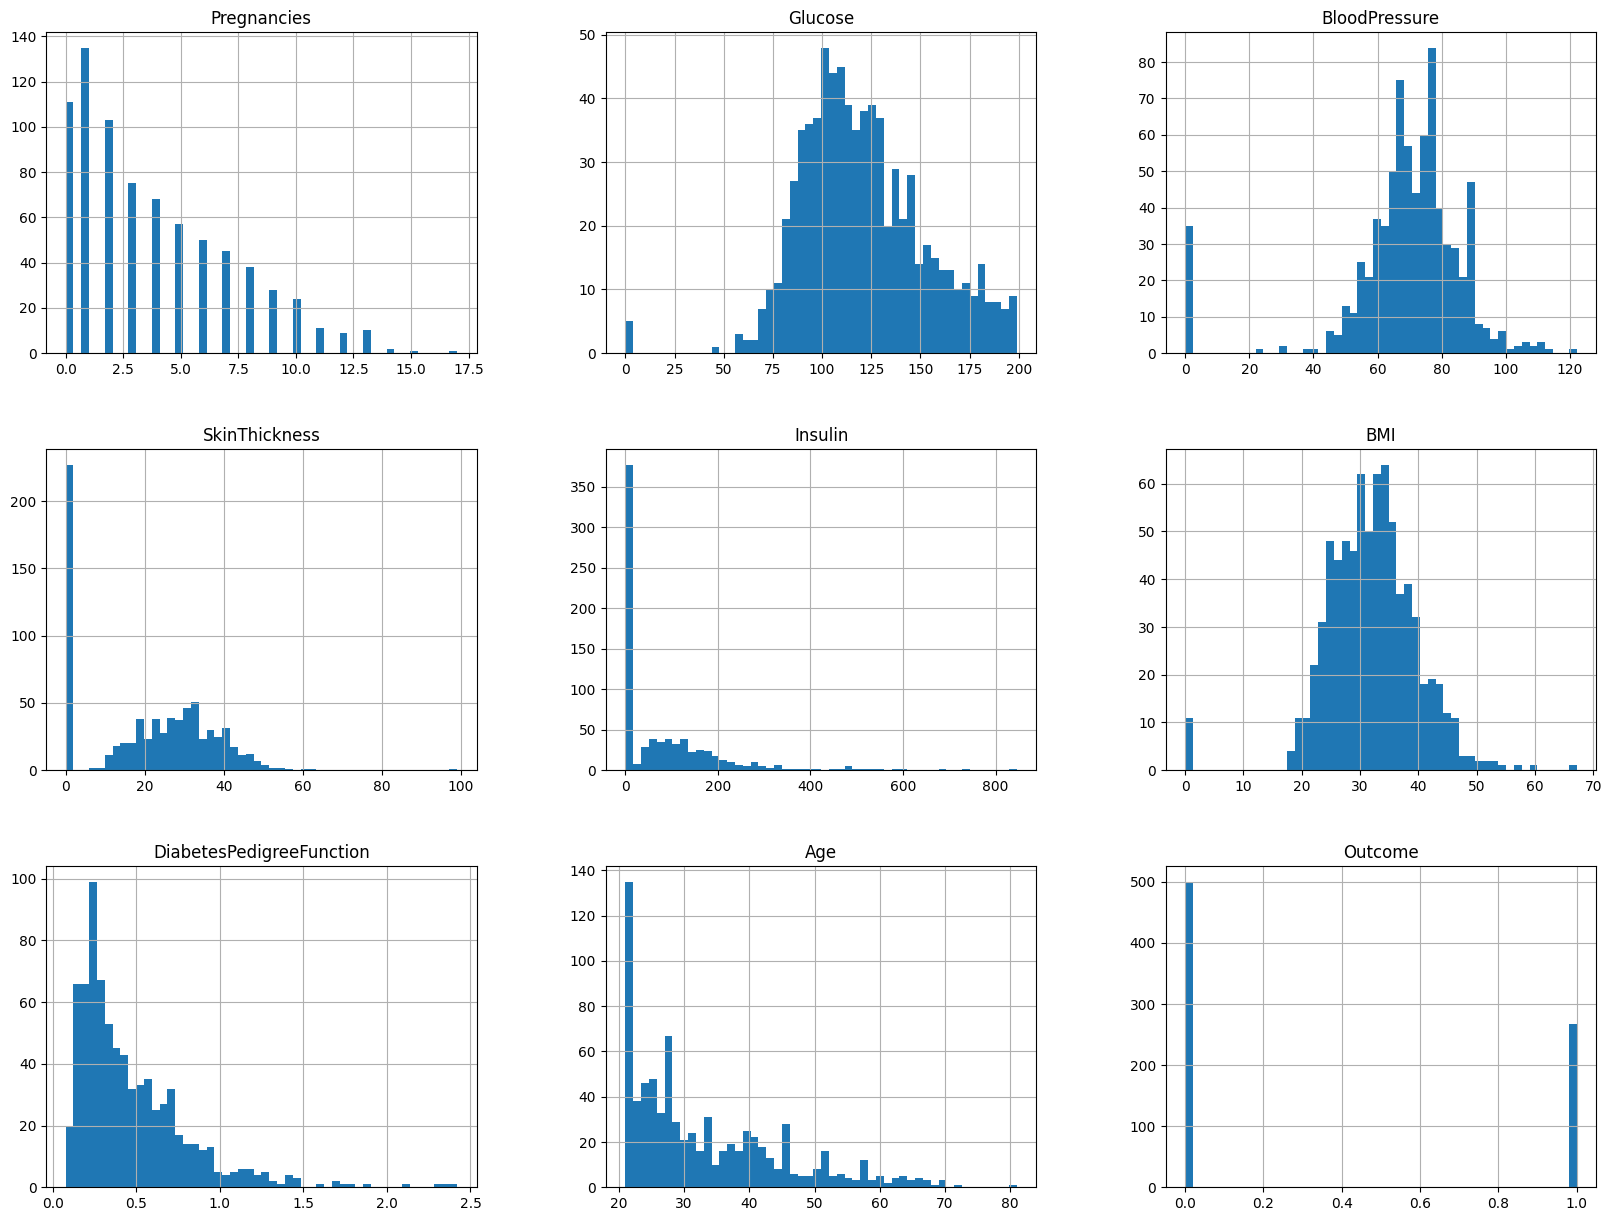

In [ ]:
#histogram
diabetes_df.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
diabetes_df3 = diabetes_df.copy()
zero_col  = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_df3[zero_col] = diabetes_df3[zero_col].replace(0, np.nan)


In [ ]:
for col in ['Glucose','Insulin','SkinThickness']:
    median_col = np.median(diabetes_df3[diabetes_df3[col].notna()][col])
    diabetes_df3[col] = diabetes_df3[col].fillna(median_col)
for col in ['BMI','BloodPressure']:
    mean_col = np.mean(diabetes_df3[diabetes_df3[col].notna()][col])
    diabetes_df3[col] = diabetes_df3[col].fillna(mean_col)

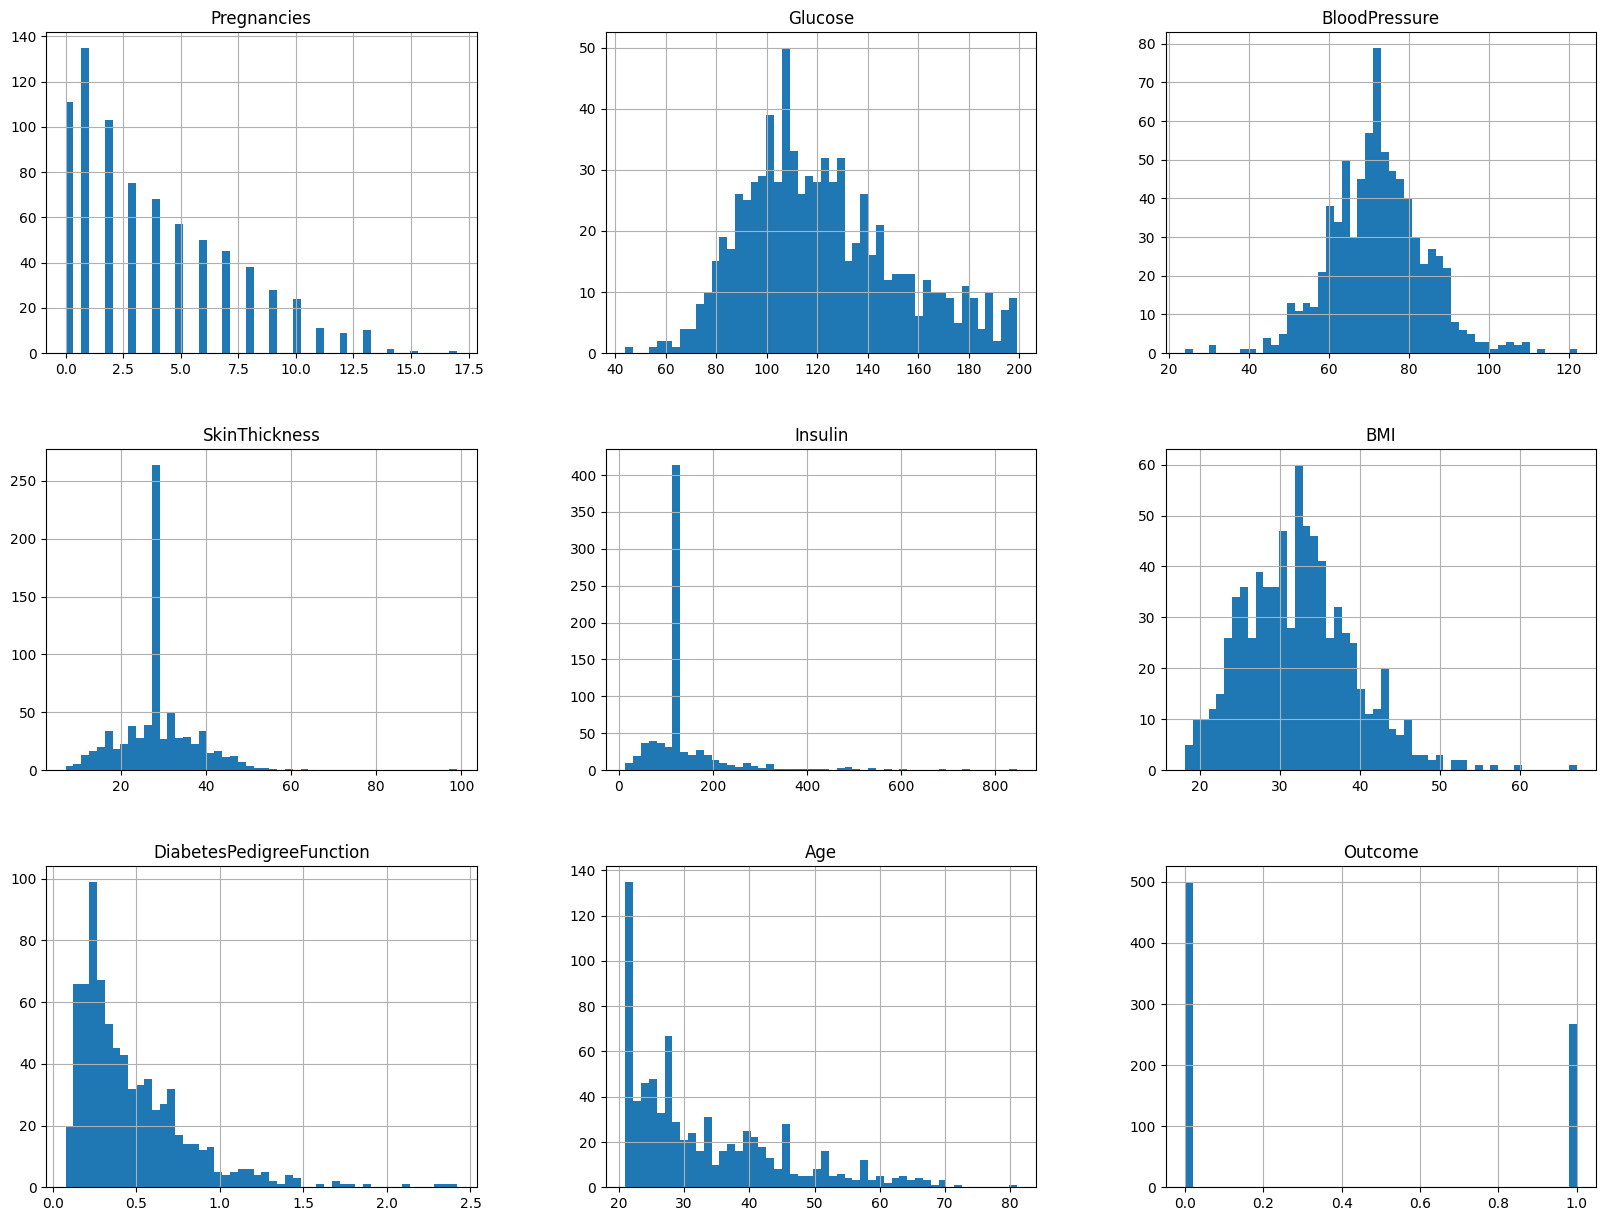

In [ ]:
#histogram
diabetes_df3.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
diabetes_df3.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


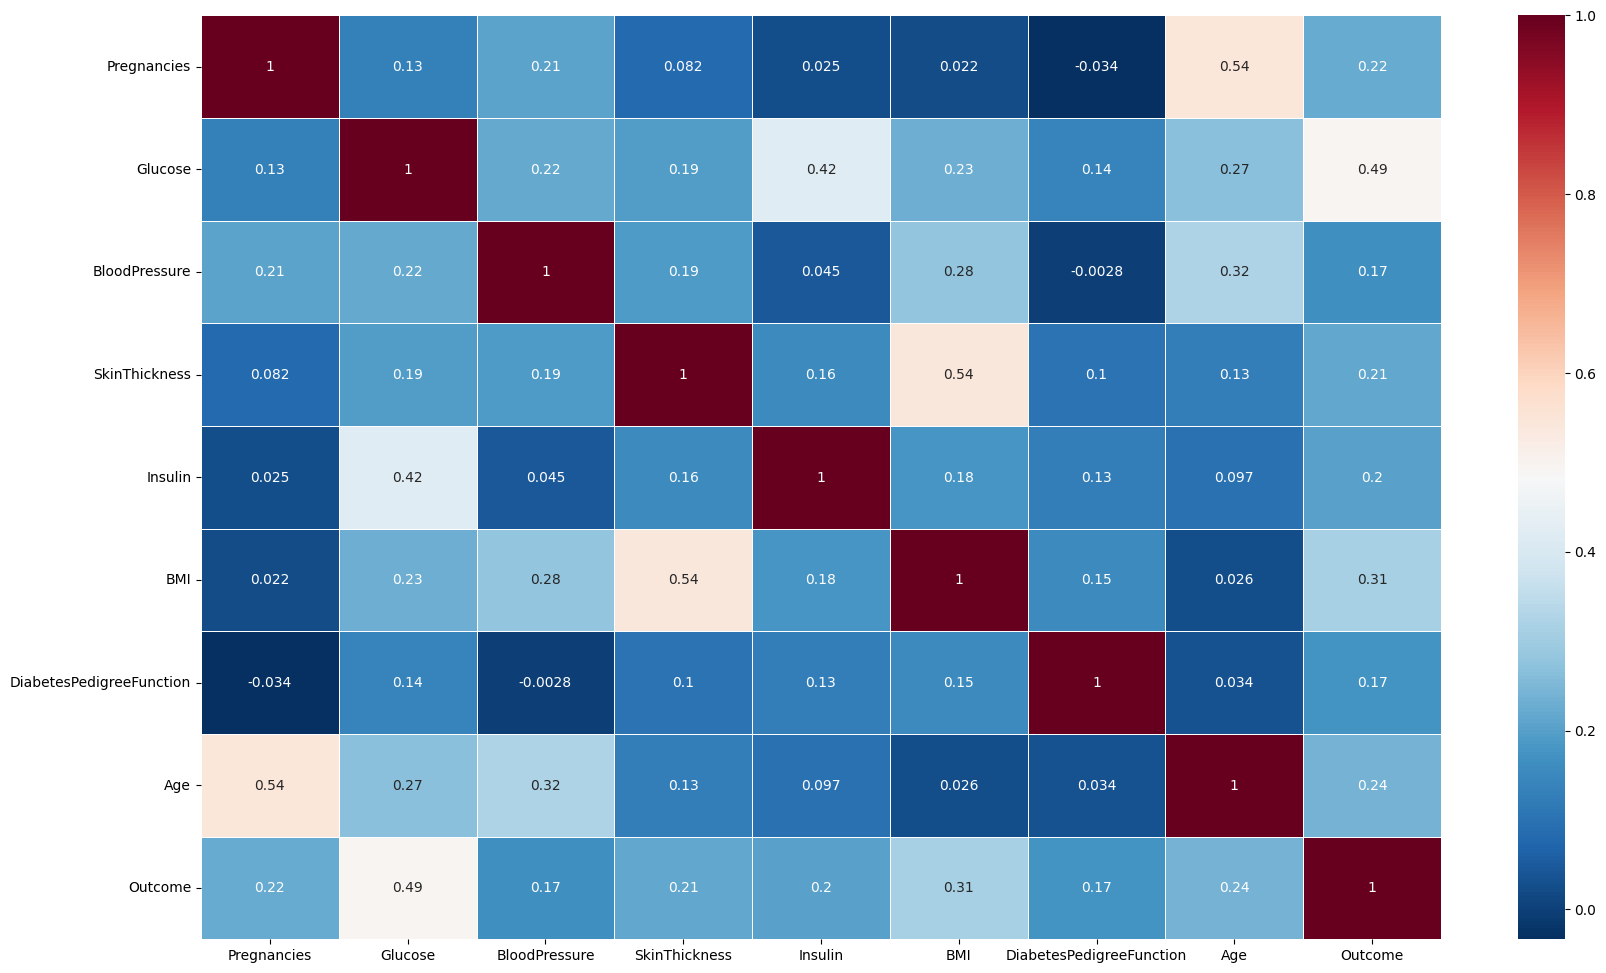

In [ ]:
## Show correlation
fig, ax = plt.subplots(figsize = (20, 12)) #Size of plot
ax = sns.heatmap(diabetes_df3.corr(),cmap='RdBu_r',cbar=True,annot=True,linewidths=0.5,ax=ax)
plt.show()

In [ ]:
#Correlation
diabetes_df3.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208522,0.081770,0.025047,0.021565,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218749,0.192615,0.419451,0.230862,0.137327,0.266909,0.492782
BloodPressure,0.208522,0.218749,1.000000,0.191853,0.045087,0.281268,-0.002763,0.324595,0.166074
SkinThickness,0.081770,0.192615,0.191853,1.000000,0.155610,0.543162,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045087,0.155610,1.000000,0.180170,0.126503,0.097101,0.203790
BMI,0.021565,0.230862,0.281268,0.543162,0.180170,1.000000,0.153400,0.025519,0.311924
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002763,0.102188,0.126503,0.153400,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324595,0.126107,0.097101,0.025519,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.166074,0.214873,0.203790,0.311924,0.173844,0.238356,1.000000


In [ ]:
diabetes_df3.corr()['Outcome'].sort_values(ascending=False) # Correlation for get information

,Outcome
Outcome,1.000000
Glucose,0.492782
BMI,0.311924
Age,0.238356
Pregnancies,0.221898
SkinThickness,0.214873
Insulin,0.203790
DiabetesPedigreeFunction,0.173844
BloodPressure,0.166074


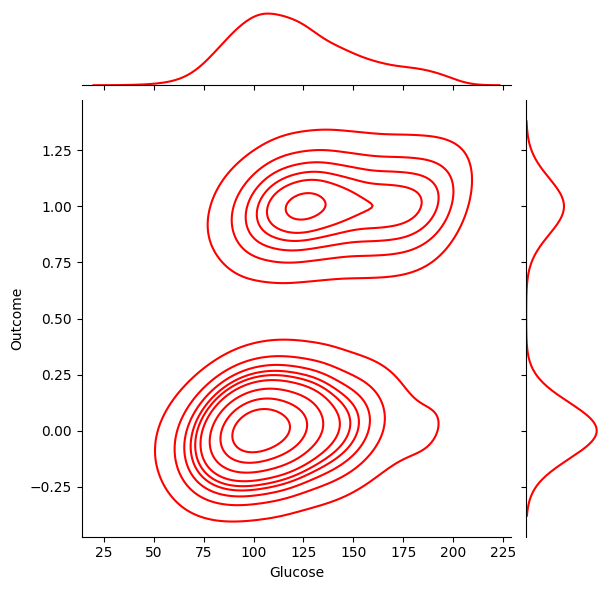

In [ ]:
#### How does Glucose is affected by price
sns.jointplot(x='Glucose',y='Outcome',data=diabetes_df3,color='red',kind='kde');

In [ ]:
# Sellecting features
X = pd.DataFrame(diabetes_df3, columns = ["Glucose","BloodPressure", "SkinThickness", "Insulin","BMI","DiabetesPedigreeFunction","Age"]).values
Y = diabetes_df3.Outcome.values.reshape(-1,1)
X

array([[148.   ,  72.   ,  35.   , ...,  33.6  ,   0.627,  50.   ],
       [ 85.   ,  66.   ,  29.   , ...,  26.6  ,   0.351,  31.   ],
       [183.   ,  64.   ,  29.   , ...,  23.3  ,   0.672,  32.   ],
       ...,
       [121.   ,  72.   ,  23.   , ...,  26.2  ,   0.245,  30.   ],
       [126.   ,  60.   ,  29.   , ...,  30.1  ,   0.349,  47.   ],
       [ 93.   ,  70.   ,  31.   , ...,  30.4  ,   0.315,  23.   ]])

In [ ]:
# Splitting the data
X_train, X_test, Y_train, Y_test  =  train_test_split(X,Y, test_size = 0.3, random_state = 0)

In [ ]:
K = 3
CLF = KNeighborsClassifier(K)
CLF.fit(X_train,Y_train.ravel() )
Y_pred = CLF.predict(X_test)

In [ ]:
# Select Best value for K
K = 20
Acc = np.zeros((K))
for i in range(1 , K+1):
    CLF = KNeighborsClassifier(n_neighbors = i)
    CLF.fit(X_train,Y_train.ravel())
    Y_pred = CLF.predict(X_test)
    Acc[i-1] = metrics.accuracy_score(Y_test, Y_pred)
Acc

array([0.63203463, 0.6969697 , 0.70995671, 0.74025974, 0.72294372,
       0.71861472, 0.71861472, 0.75757576, 0.74891775, 0.74891775,
       0.74458874, 0.73593074, 0.73160173, 0.74025974, 0.74458874,
       0.74891775, 0.74891775, 0.74891775, 0.75757576, 0.74025974])

In [ ]:
# Show max & min
print(np.max(Acc))
print(np.min(Acc))

0.7575757575757576
0.6320346320346321


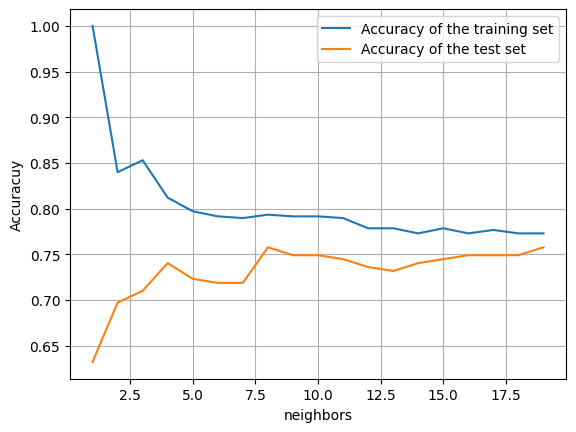

In [ ]:
########  Another way

traing_acc = []
test_acc = []
# try KNN for diffrent k nearset neighbor from 1 ta 50
neighbors_setting = range(1,20)

for n_neighbors in neighbors_setting:
    knn = KNeighborsClassifier(n_neighbors = n_neighbors)
    knn.fit(X_train,Y_train.ravel())
    traing_acc.append(knn.score(X_train,Y_train))
    test_acc.append(knn.score(X_test, Y_test))

plt.plot(neighbors_setting, traing_acc, label = "Accuracy of the training set")
plt.plot(neighbors_setting, test_acc, label = "Accuracy of the test set")
plt.ylabel("Accuracuy")
plt.xlabel("neighbors")
plt.grid()
plt.legend()


In [ ]:
#### Improval Model

from sklearn.model_selection import GridSearchCV
parametrs = {"n_neighbors": range(1,20) }
grid_kn = GridSearchCV(estimator = knn, #Model
                       param_grid = parametrs, #Range of K
                       scoring = "accuracy",
                       cv = 5,          # cross validation generator
                       verbose = 1,     #Time of calculate
                       n_jobs = -1)     #help to cpu



grid_kn.fit(X_train, Y_train.ravel())

Fitting 5 folds for each of 19 candidates, totalling 95 fits


GridSearchCV(cv=5, estimator=KNeighborsClassifier(n_neighbors=19), n_jobs=-1,
             param_grid={'n_neighbors': range(1, 20)}, scoring='accuracy',
             verbose=1)

In [ ]:
CLF.score(X,Y)

0.7604166666666666

In [ ]:
print("Accuracy:" , metrics.accuracy_score(Y_test,Y_pred ))

Accuracy: 0.7402597402597403


In [ ]:
confusion_matrix(Y,CLF.predict(X))

array([[440,  60],
       [124, 144]])

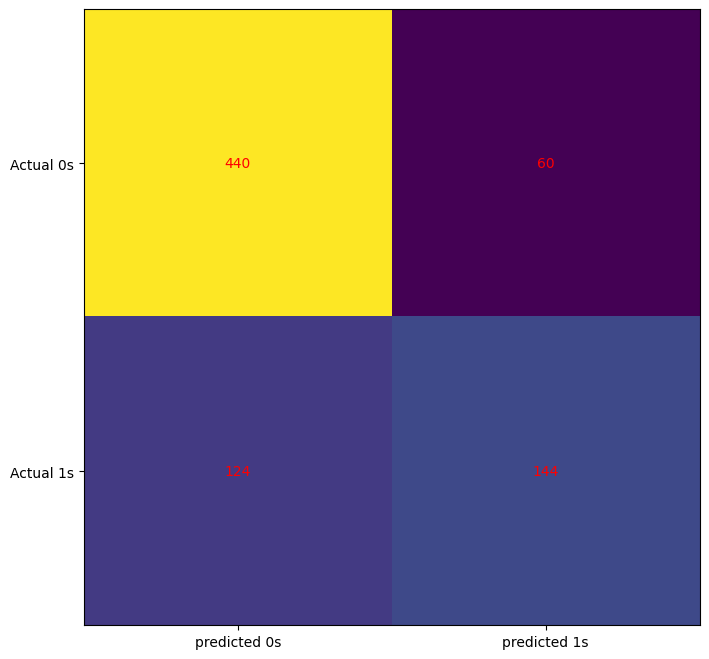

In [ ]:
# Show plot for confusion matrix
cm = confusion_matrix(Y, CLF.predict(X))
fig , ax = plt.subplots(figsize = (8,8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks = (0,1) , ticklabels = ("predicted 0s", "predicted 1s"))
ax.yaxis.set(ticks = (0,1) , ticklabels = ("Actual 0s", "Actual 1s"))
ax.set_ylim(1.5 , -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i , cm[i,j], ha = "center" , va = "center", color = "red")
plt.show()

In [ ]:
# Calculate classification
print(classification_report(Y, CLF.predict(X)))

              precision    recall  f1-score   support

           0       0.78      0.88      0.83       500
           1       0.71      0.54      0.61       268

    accuracy                           0.76       768
   macro avg       0.74      0.71      0.72       768
weighted avg       0.75      0.76      0.75       768



In [ ]:
# Sellecting features
X = pd.DataFrame(diabetes_df3 , columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"])
Y = diabetes_df3.Outcome

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.25, random_state =0)

In [ ]:
Logreg = LogisticRegression(solver = "liblinear")

In [ ]:
Logreg.fit(X_train , Y_train)
Y_pred = Logreg.predict(X_test)

In [ ]:
Y_pred

array([1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [ ]:
print("Accuracy:" , metrics.accuracy_score(Y_test,Y_pred ))

Accuracy: 0.7708333333333334


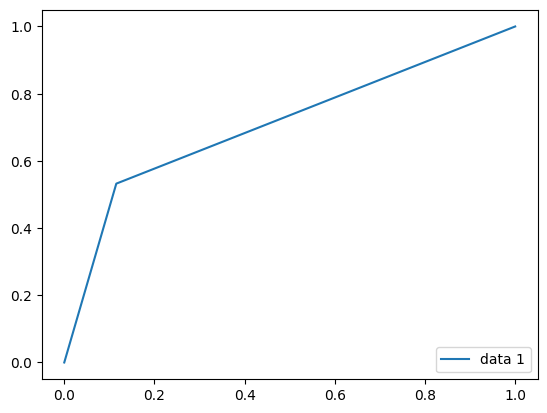

In [ ]:
fpr , tpr,_ = metrics.roc_curve(Y_test,Y_pred)
plt.plot(fpr , tpr, label = "data 1")
plt.legend(loc = 4)
plt.show()

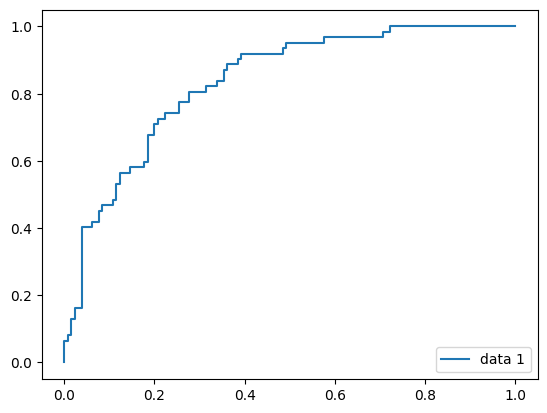

In [ ]:
Y_pred_proba = Logreg.predict_proba(X_test)[::,1]
fpr , tpr,_ = metrics.roc_curve(Y_test,Y_pred_proba)
plt.plot(fpr , tpr, label = "data 1")
plt.legend(loc = 4)
plt.show()

In [ ]:
Logreg.classes_

array([0, 1])

In [ ]:
Logreg.intercept_

array([-5.09559785])

In [ ]:
Logreg.coef_

array([[ 0.09137022,  0.0305919 , -0.03388062, -0.01177504, -0.00089646,
         0.07655121,  0.58681836,  0.01490288]])

In [ ]:
Logreg.predict_proba(X)

array([[0.3314055 , 0.6685945 ],
       [0.91601131, 0.08398869],
       [0.21982874, 0.78017126],
       ...,
       [0.75974154, 0.24025846],
       [0.60505991, 0.39494009],
       [0.89596164, 0.10403836]])

In [ ]:
Logreg.score(X,Y)

0.7682291666666666

In [ ]:
confusion_matrix(Y,Logreg.predict(X))

array([[442,  58],
       [120, 148]])

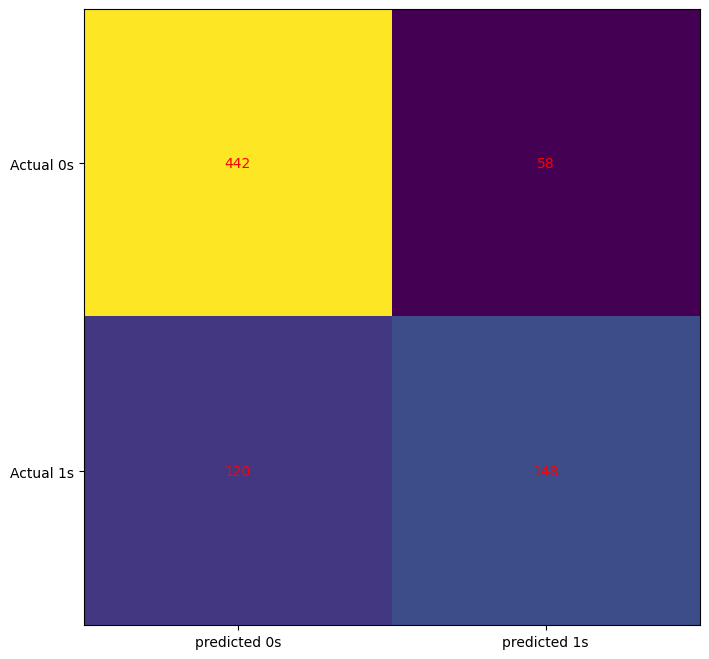

In [ ]:
# show plot for confusion matrix
cm = confusion_matrix(Y, Logreg.predict(X))
fig , ax = plt.subplots(figsize = (8,8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks = (0,1) , ticklabels = ("predicted 0s", "predicted 1s"))
ax.yaxis.set(ticks = (0,1) , ticklabels = ("Actual 0s", "Actual 1s"))
ax.set_ylim(1.5 , -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i , cm[i,j], ha = "center" , va = "center", color = "red")
plt.show()

In [ ]:
print(classification_report(Y, Logreg.predict(X)))

              precision    recall  f1-score   support

           0       0.79      0.88      0.83       500
           1       0.72      0.55      0.62       268

    accuracy                           0.77       768
   macro avg       0.75      0.72      0.73       768
weighted avg       0.76      0.77      0.76       768



In [ ]:
# Sellecting features
X = pd.DataFrame(diabetes_df3 , columns = ["Pregnancies","Glucose","BloodPressure","SkinThickness","Insulin","BMI","DiabetesPedigreeFunction","Age"])
Y = diabetes_df3.Outcome

In [ ]:
# Splitting the data

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size = 0.25 ,random_state = 1)

In [ ]:
#Model
clf_svm = SVC(C=10.0)
clf_svm = clf_svm.fit(X_train,Y_train )
y_pred = clf_svm.predict(X_test)

In [ ]:
print("Accuracy: ", metrics.accuracy_score(Y_test, y_pred))

Accuracy:  0.765625


In [ ]:
confusion_matrix(Y, clf_svm.predict(X))

array([[457,  43],
       [124, 144]])

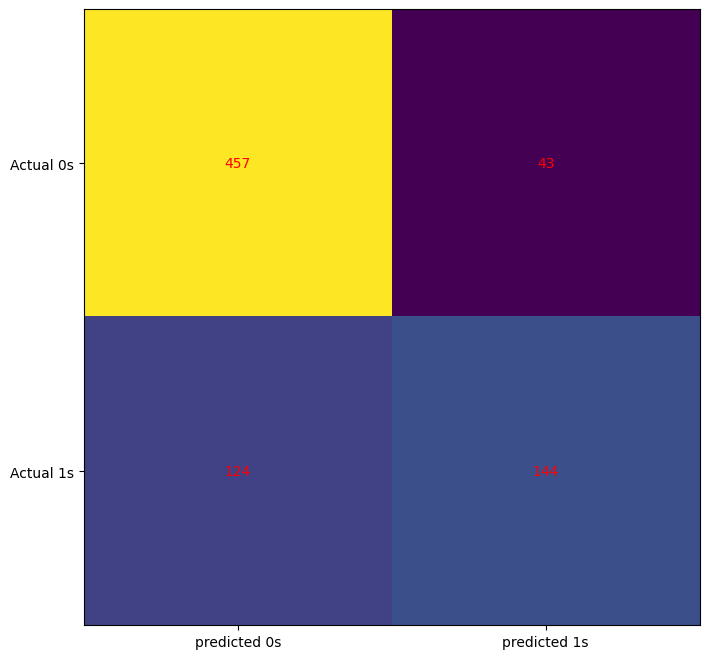

In [ ]:
# show plot for confusion matrix
cm = confusion_matrix(Y, clf_svm.predict(X))
fig , ax = plt.subplots(figsize = (8,8))
ax.imshow(cm)
ax.grid(False)
ax.xaxis.set(ticks = (0,1) , ticklabels = ("predicted 0s", "predicted 1s"))
ax.yaxis.set(ticks = (0,1) , ticklabels = ("Actual 0s", "Actual 1s"))
ax.set_ylim(1.5 , -0.5)
for i in range(2):
    for j in range(2):
        ax.text(j, i , cm[i,j], ha = "center" , va = "center", color = "red")
plt.show()